## Exercício 1: Ângulos entre vetores aleatórios em alta dimensão

### Objetivo
Explorar como o ângulo entre vetores aleatórios muda com o aumento da dimensão do espaço vetorial.

### Descrição
Você irá gerar pares de vetores aleatórios com componentes independentes e distribuídos segundo uma normal padrão $ \mathcal{N}(0, 1) $, e calcular o ângulo entre eles em diferentes dimensões.

### Etapas sugeridas ✅

1. Para cada dimensão $d \in \{2, 5, 10, 20, 50, 100, 200, 500, 1000\}$: ✅
   - Gere dois vetores aleatórios $ a, b \in \mathbb{R}^d $, com entradas iid $ \sim \mathcal{N}(0,1) $.
     - *Dica*: use `np.random.normal(loc=0, scale=1, size=d)`
   - Calcule o produto escalar \( \langle a, b \rangle \).
     - *Dica*: use `np.dot(a, b)`
   - Calcule as normas $ \|a\| $ e $ \|b\| $.
     - *Dica*: use `np.linalg.norm(v)`
   - Obtenha o cosseno do ângulo:
     $$
     \cos(\theta) = \frac{\langle a, b \rangle}{\|a\| \cdot \|b\|}
     $$
   - Calcule o ângulo $ \theta $ (em radianos ou graus).
     - *Dica*: use `np.arccos(...)` e depois `np.degrees(...)` se quiser converter para graus.

2. Repita esse procedimento para vários pares (ex: 1000) e plote o **histograma dos ângulos** obtidos para cada dimensão. ✅

### Perguntas para reflexão

- Como os ângulos se distribuem em dimensões baixas? R: Cada vez mais ortogonais, ou seja, mais proximos de 90 graus
- O que acontece com essa distribuição conforme a dimensão aumenta? R: a variancia diminui
- Por que, em alta dimensão, os vetores aleatórios tendem a formar ângulos próximos de 90 graus?
  - Tente justificar essa observação com base nas propriedades da distribuição normal e no comportamento do produto escalar e das normas em alta dimensão.


## Exercício 2: Volume da bola unitária dentro do cubo em alta dimensão

### Objetivo
Investigar como o volume da bola unitária se comporta em relação ao volume do cubo que a contém, conforme a dimensão aumenta.

### Fenômeno observado
O volume da bola unitária centrada na origem, contida no cubo $[-1, 1]^d$, **tende a zero** com o aumento da dimensão $d$.

### Tarefa

1. Para cada dimensão $d \in \{1, 2, 3, \dots, 20\}$: ✅
   - Gere $n$ pontos aleatórios com distribuição uniforme no cubo $[-1, 1]^d$.
     - *Dica*: use `np.random.uniform(-1, 1, size=(n, d))`
   - Calcule a norma euclidiana de cada ponto.
     - *Dica*: use `np.linalg.norm(...)` ao longo do eixo 1.
   - Verifique quantos pontos caem dentro da **bola de raio 1** centrada na origem.
   - Estime o volume da bola pela proporção de pontos que caem dentro, multiplicada pelo volume do cubo $2^d$.

2. Para comparação, calcule o **volume teórico da bola unitária** em $d$ dimensões: ✅
   $$
   V_d = \frac{\pi^{d/2}}{\Gamma(d/2 + 1)}
   $$
   - *Dica*: use `scipy.special.gamma` para calcular a função gama.


### Perguntas para reflexão

- O que acontece com o volume da bola unitária conforme a dimensão cresce?
- Por que o volume estimado tende a zero, mesmo com muitos pontos?
- O que isso nos diz sobre a concentração da massa em espaços de alta dimensão?


## Exercício 3: Concentração da massa na casca da bola unitária

### Objetivo
Investigar como, em alta dimensão, a maior parte da massa da bola unitária se concentra em uma casca fina próxima da superfície.

### Fenômeno observado
Para pontos gerados uniformemente dentro da bola unitária de $\mathbb{R}^d$, a maioria se concentra em uma fina camada próxima do raio 1 — ou seja, a massa se acumula na casca da bola quando $d$ cresce.

---

### Parte 1: Método geral de amostragem uniforme na bola unitária

Para gerar um ponto uniforme dentro da bola unitária em $\mathbb{R}^d$, faça:

1. Amostre um vetor $z \sim \mathcal{N}(0, I_d)$ (entradas independentes padrão-normal).
2. Normalize: $z_{\text{unit}} = z / \|z\|$ (direção uniforme na esfera).
3. Sorteie $u \sim \text{Uniform}(0, 1)$.
4. Defina o raio como $r = u^{1/d}$.
5. O ponto amostrado é: $x = r \cdot z_{\text{unit}}$.

---

### Parte 2: Verificação visual no plano (caso $d = 2$)

Implemente o método acima com $d = 2$ e $n$ grande (por exemplo, $n = 10000$). Plote os pontos gerados no plano.

---

### Parte 3: Concentração da massa em alta dimensão

1. Para cada dimensão $d \in \{2, 5, 10, 20, 50, 100, 200\}$:
   - Gere $n$ pontos usando o método geral de amostragem descrito acima.
   - Para cada ponto, calcule a norma euclidiana $\|x\|$ (distância à origem).

2. Plote um **histograma das normas** para cada dimensão.

3. Calcule a **fração de pontos** cuja norma está no intervalo $[1 - \varepsilon, 1]$, com $\varepsilon = 0{,}01$ ou $0{,}05$.

---

### Perguntas para reflexão

- Como se comporta a distribuição das distâncias à origem conforme a dimensão aumenta?
- A que distância da origem estão a maioria dos pontos?
- Qual é a consequência prática desse fenômeno para algoritmos que dependem de densidade ou centralidade?


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

sns.set_theme()

# 1

In [2]:
results = []
dimensoes = [2,5,10,20,50,100,200,500,1000,10000]
for d in dimensoes:
    tmp=[]
    for _ in range(10000):
        a = np.random.normal(loc=0, scale=1, size=d)
        b = np.random.normal(loc=0, scale=1, size=d)

        cos = np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
        theta = np.degrees(np.arccos(cos))

        tmp.append(theta)

    results.append(tmp)


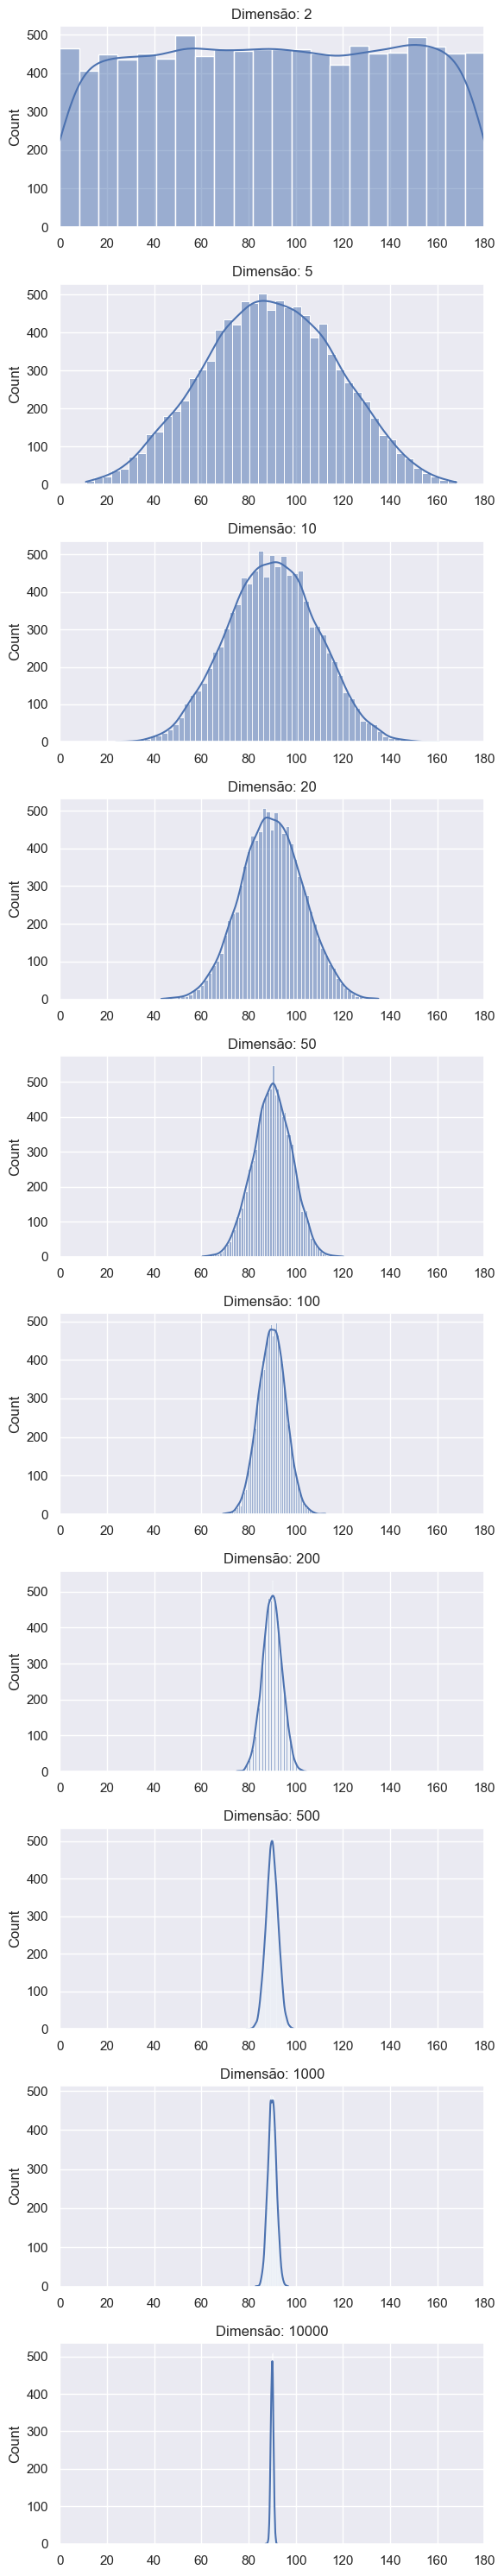

In [3]:
fig, axs = plt.subplots(nrows=len(dimensoes), ncols=1, figsize=(6, 3*len(dimensoes)))

for ax, title, theta in zip(axs, dimensoes, results):
    sns.histplot(theta, ax=ax, kde=True)
    ax.set_title(f'Dimensão: {title}')
    ax.set_xlim([0, 180])

fig.tight_layout()

# 2

Text(0.5, 1.0, '$V_e$: 3.080, $V_t$: 3.142')

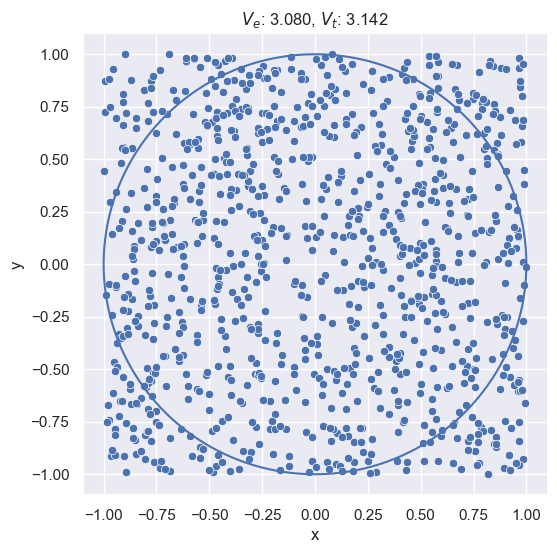

In [21]:
d = 2
n = 1000

pontos = np.random.uniform(-1,1, size=(n, d))
norm = np.linalg.norm(pontos, axis=1)

inside_bola = np.mean(norm <= 1)
volume = 2**d * inside_bola
volume_teorico = (np.pi**(d/2))/scipy.special.gamma(d/2+1)

### Plots
fig, ax = plt.subplots(1,1,figsize=(6, 6))

sns.scatterplot(
    data=pd.DataFrame(pontos, columns=['x', 'y']),
    x='x',
    y='y',
    ax=ax
)

theta = np.linspace(0, 2 * np.pi, 500)
x = np.cos(theta)
y = np.sin(theta)

ax.plot(x, y)

ax.set_title(f"$V_e$: {volume:.3f}, $V_t$: {volume_teorico:.3f}")

Text(0.5, 0.92, '$V_e$: 4.256, $V_t$: 4.189')

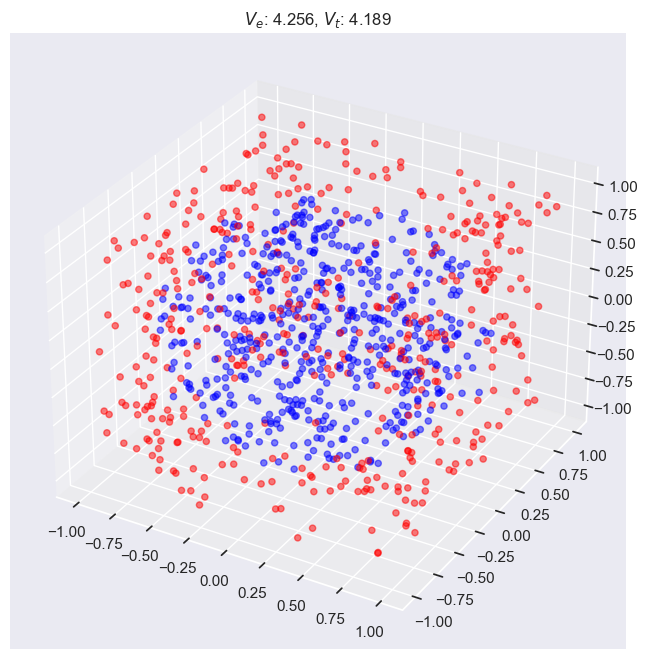

In [23]:
d = 3
n = 1000

pontos = np.random.uniform(-1,1, size=(n, d))
norm = np.linalg.norm(pontos, axis=1)

inside_bola = np.mean(norm <= 1)
volume = 2**d * inside_bola
volume_teorico = (np.pi**(d/2))/scipy.special.gamma(d/2+1)

### Plots
plot_data = pd.DataFrame(pontos, columns=['x', 'y', 'z'])
plot_data['inside'] = norm <= 1

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

colors = plot_data['inside'].map({True: 'blue', False: 'red'})

ax.scatter(plot_data['x'], plot_data['y'], plot_data['z'], c=colors, alpha=0.5)

ax.set_title(f"$V_e$: {volume:.3f}, $V_t$: {volume_teorico:.3f}")

<Axes: xlabel='dim', ylabel='volume'>

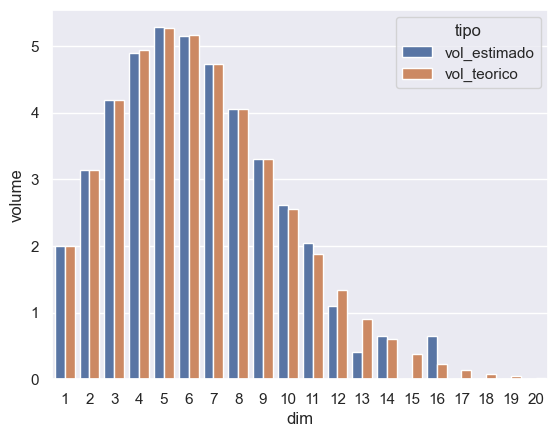

In [28]:
# O que acontece com o volume da bola unitária conforme a dimensão cresce?

d_list = np.arange(1, 21)
n = 100000

ve = []
vt = []
for d in d_list:
    pontos = np.random.uniform(-1,1, size=(n, d))
    norm = np.linalg.norm(pontos, axis=1)

    inside_bola = np.mean(norm <= 1)
    volume = 2**d * inside_bola
    volume_teorico = (np.pi**(d/2))/scipy.special.gamma(d/2+1)
    ve.append(volume)
    vt.append(volume_teorico)

plot_df = pd.DataFrame(zip(d_list, ve, vt), columns=['dim', 'vol_estimado', 'vol_teorico'])

plot_df = plot_df.melt(
    id_vars='dim',
    value_vars=['vol_estimado', 'vol_teorico'],
    var_name='tipo',
    value_name='volume'
)

sns.barplot(data=plot_df, x='dim', y='volume', hue='tipo')

# 3

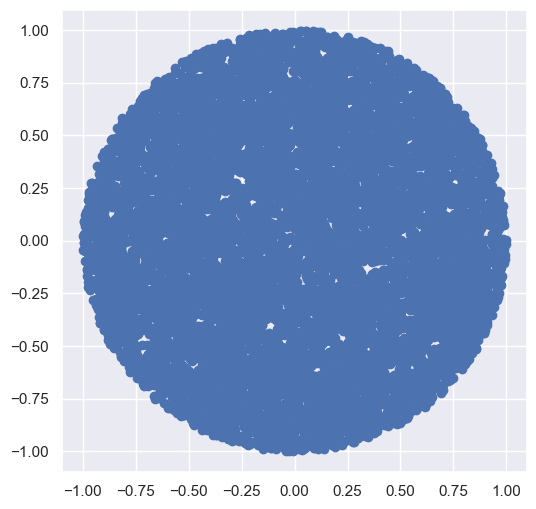

In [54]:
n = 10000
d = 2
z = np.random.randn(n, d)
z_unit = z / np.linalg.norm(z, axis=1, keepdims=True)
u = np.random.uniform(0, 1, size=(n, 1))
r = u**(1/d)
x = r * z_unit

plt.figure(figsize=(6, 6))
plt.scatter(x[:,0],x[:,1])

In [ ]:
n = 10000
d = 2
z = np.random.randn(n, d)
z_unit = z / np.linalg.norm(z, axis=1, keepdims=True)
u = np.random.uniform(0, 1, size=(n, 1))
r = u**(1/d)
x = r * z_unit

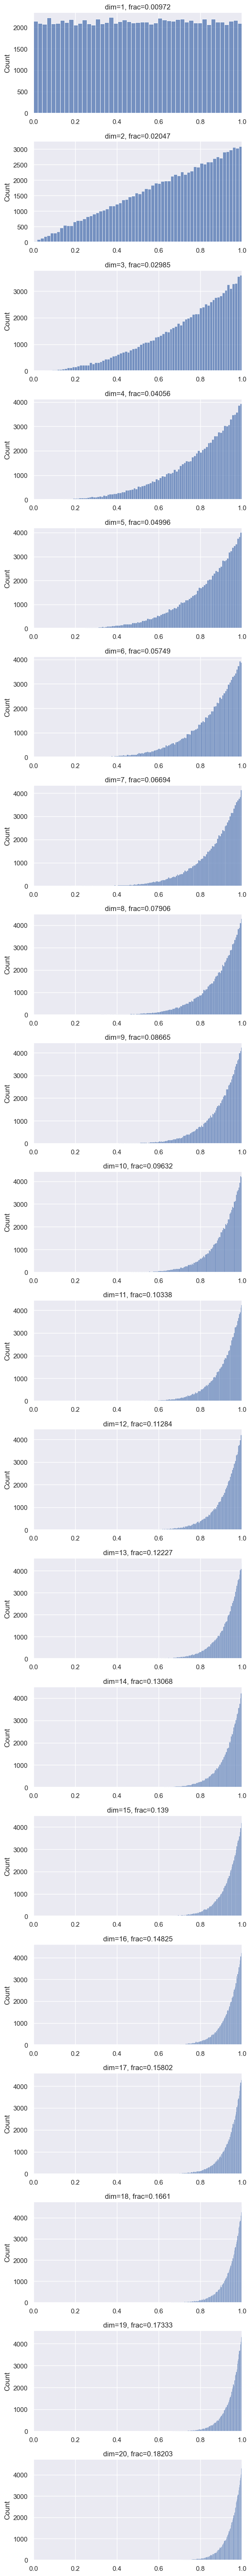

In [56]:
d_list = np.arange(1, 21)
n = 100000

ve = []
vt = []

fig, axs = plt.subplots(len(d_list),1, figsize=(6, 3*len(d_list)))
for d, ax in zip(d_list, axs):
    z = np.random.randn(n, d)
    z_unit = z / np.linalg.norm(z, axis=1, keepdims=True)
    u = np.random.uniform(0, 1, size=(n, 1))
    r = u**(1/d)
    x = r * z_unit
    norm = np.linalg.norm(x, axis=1)

    sns.histplot(norm, ax=ax)
    ax.set_title(f"dim={d}, frac={np.mean((norm<=1) & (norm>1-0.01))}")
    ax.set_xlim([0, 1])

fig.tight_layout()